# 09 — Final test evaluation
The only notebook that reads the test set. Each checkpoint is scored once and the result is stored.
Can run before notebook 10 (seed 42 only); run it again after notebook 10 to add seeds 43/44 — the seed-42 results are reused, not recomputed.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!git -C /content/realwaste-classification pull -q || git clone -q https://github.com/KNV-DSEB/realwaste-classification.git /content/realwaste-classification
import sys
sys.path.insert(0, "/content/realwaste-classification")
for m in [m for m in sys.modules if m.split(".")[0] == "src"]:
    del sys.modules[m]  # re-import the code just pulled

In [6]:
import pandas as pd
import torch
from IPython.display import Image, display
from src.dataset import load_frozen_split
from src.final_eval import comparison_table, evaluate_experiment, per_class_f1_table
from src.utils import get_paths, load_config

cfg = load_config()
split_df = load_frozen_split(cfg)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
res_dir = get_paths(cfg).result_dir
(res_dir / "final").mkdir(exist_ok=True)

In [7]:
results = {exp: evaluate_experiment(cfg, exp, split_df, device, amp=device.type == "cuda")
           for exp in ["E1", "E2", "E3", "E4"]}

table = comparison_table(results)
per_class = per_class_f1_table(cfg, list(results))
table.to_csv(res_dir / "final" / "model_comparison.csv", index=False)
per_class.to_csv(res_dir / "final" / "per_class_f1.csv")
print(table.to_string(index=False))
print(per_class.round(3).to_string())

E1: seeds 43/44 not run yet (notebook 10), evaluating seed 42 only
E1 base: test accuracy 0.7058, macro-F1 0.7052
E2: seeds 43/44 not run yet (notebook 10), evaluating seed 42 only
E2 base: test accuracy 0.8006, macro-F1 0.8051
E3: seeds 43/44 not run yet (notebook 10), evaluating seed 42 only
E3 base: test accuracy 0.9010, macro-F1 0.8977
E4 base: test accuracy 0.8317, macro-F1 0.8351
experiment               model  seeds  accuracy accuracy_sd  macro_precision macro_precision_sd  macro_recall macro_recall_sd  macro_f1 macro_f1_sd  best_val_macro_f1 best_val_macro_f1_sd
        E1           SimpleCNN      1    0.7058        None           0.7153               None        0.7073            None    0.7052        None             0.6499                 None
        E2       MultiScaleCNN      1    0.8006        None           0.8105               None        0.8054            None    0.8051        None             0.7873                 None
        E3     EfficientNet-B0      1    0.9010

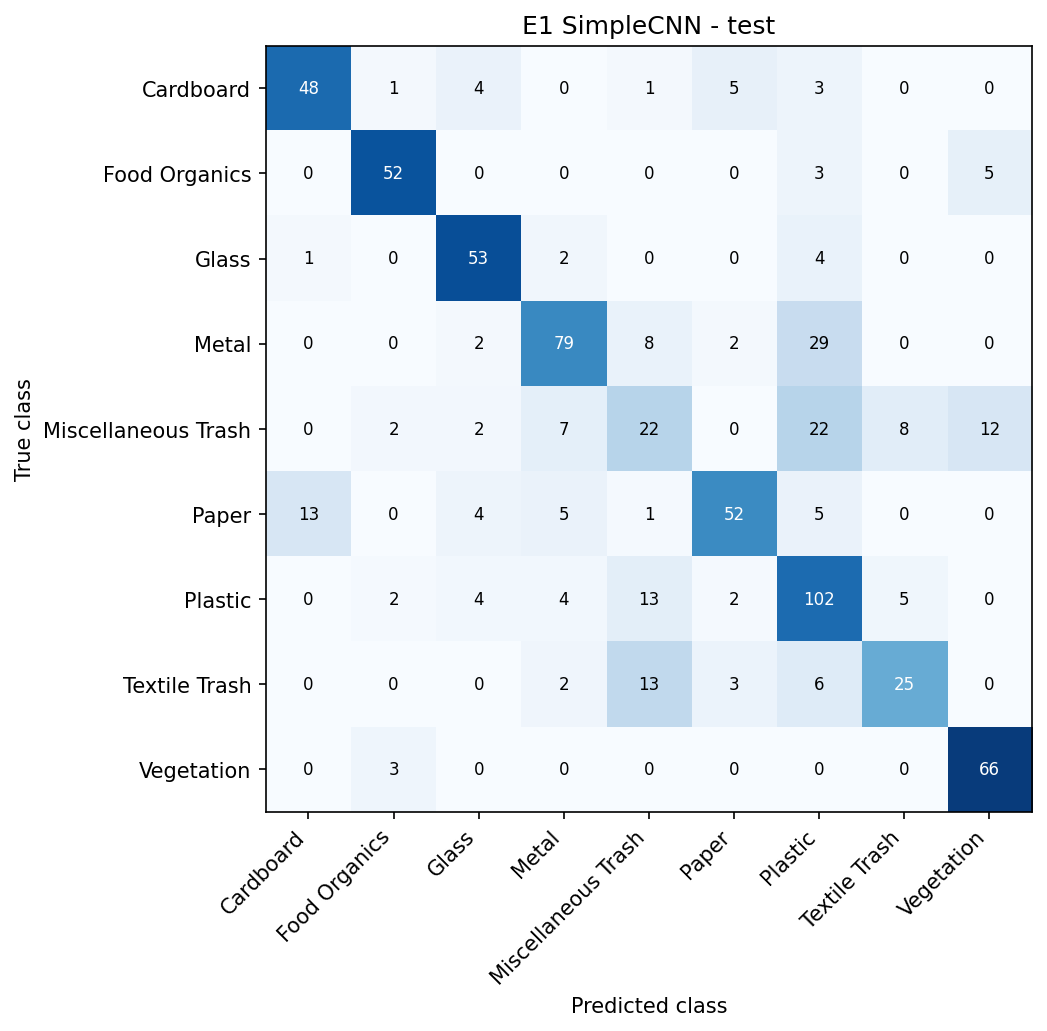

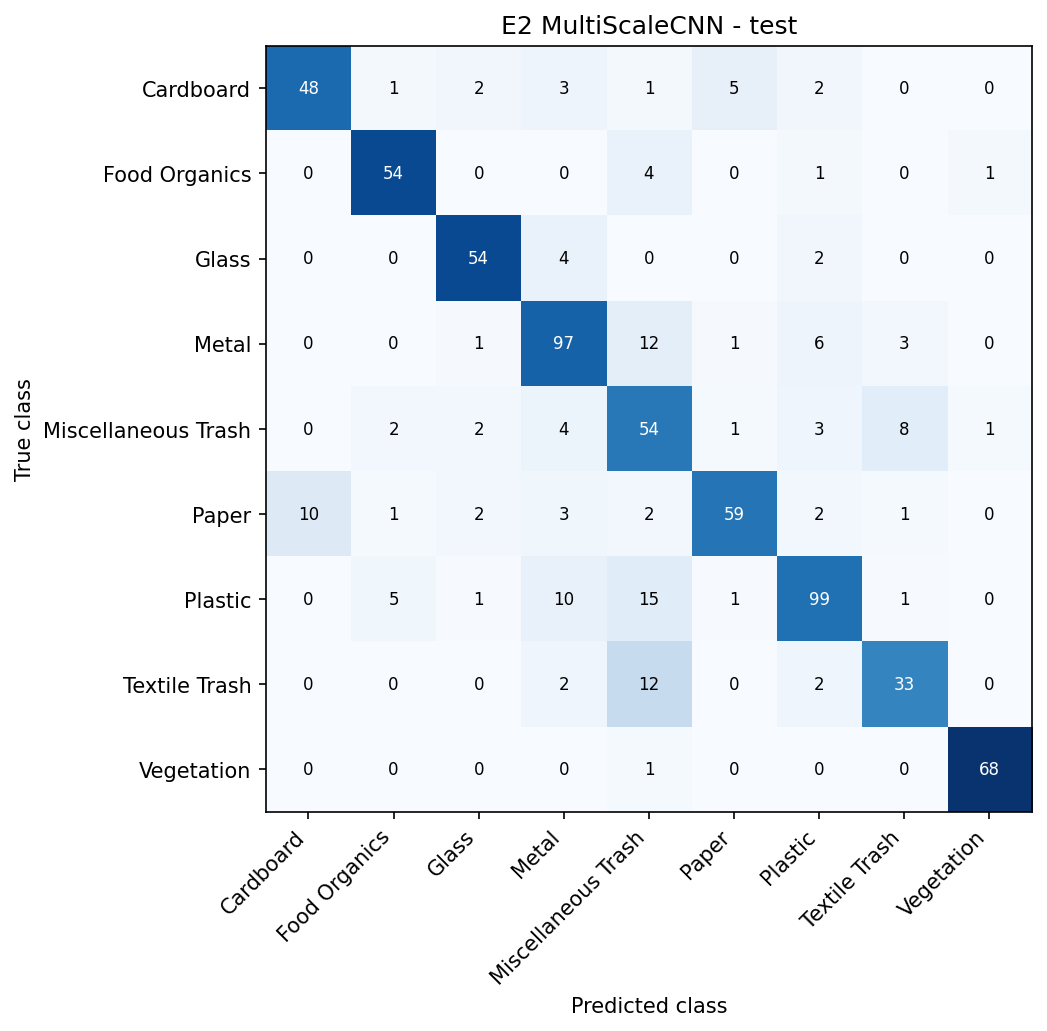

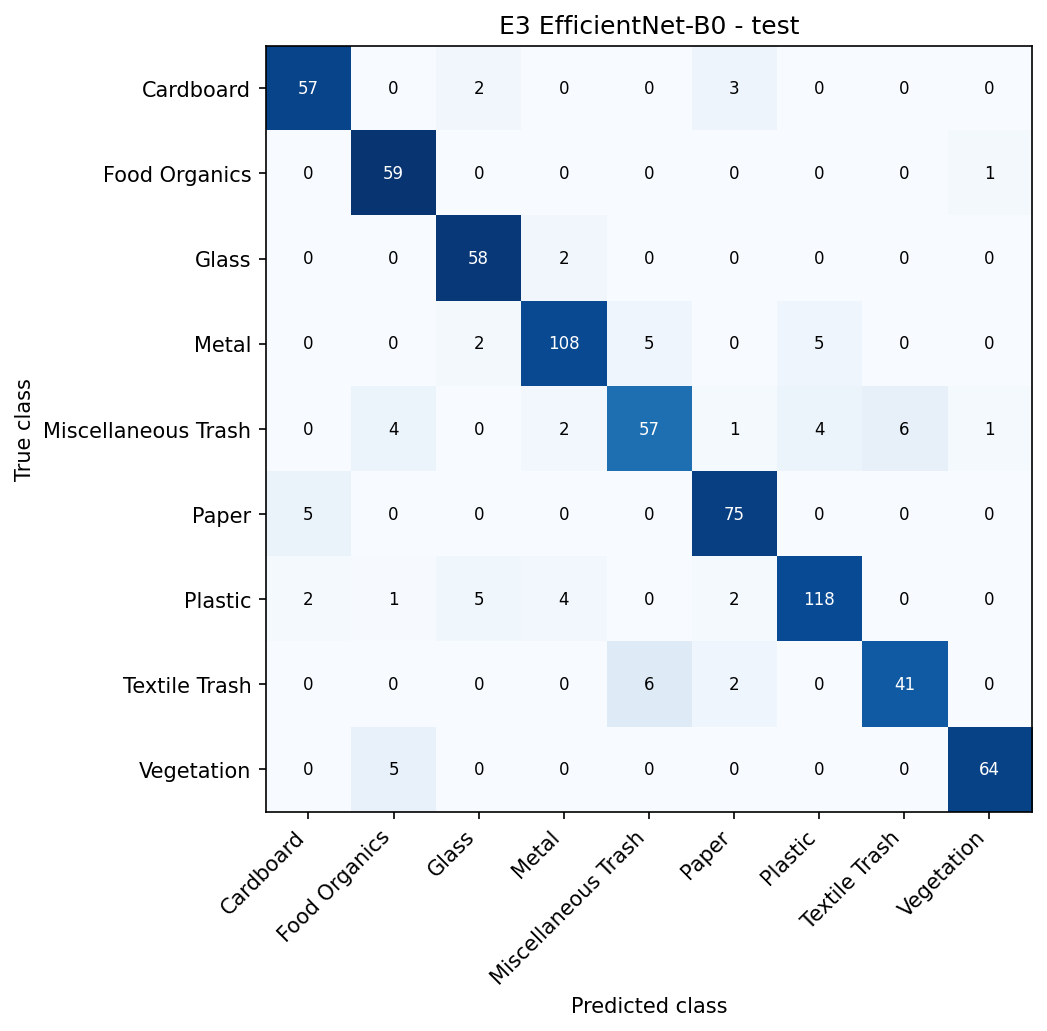

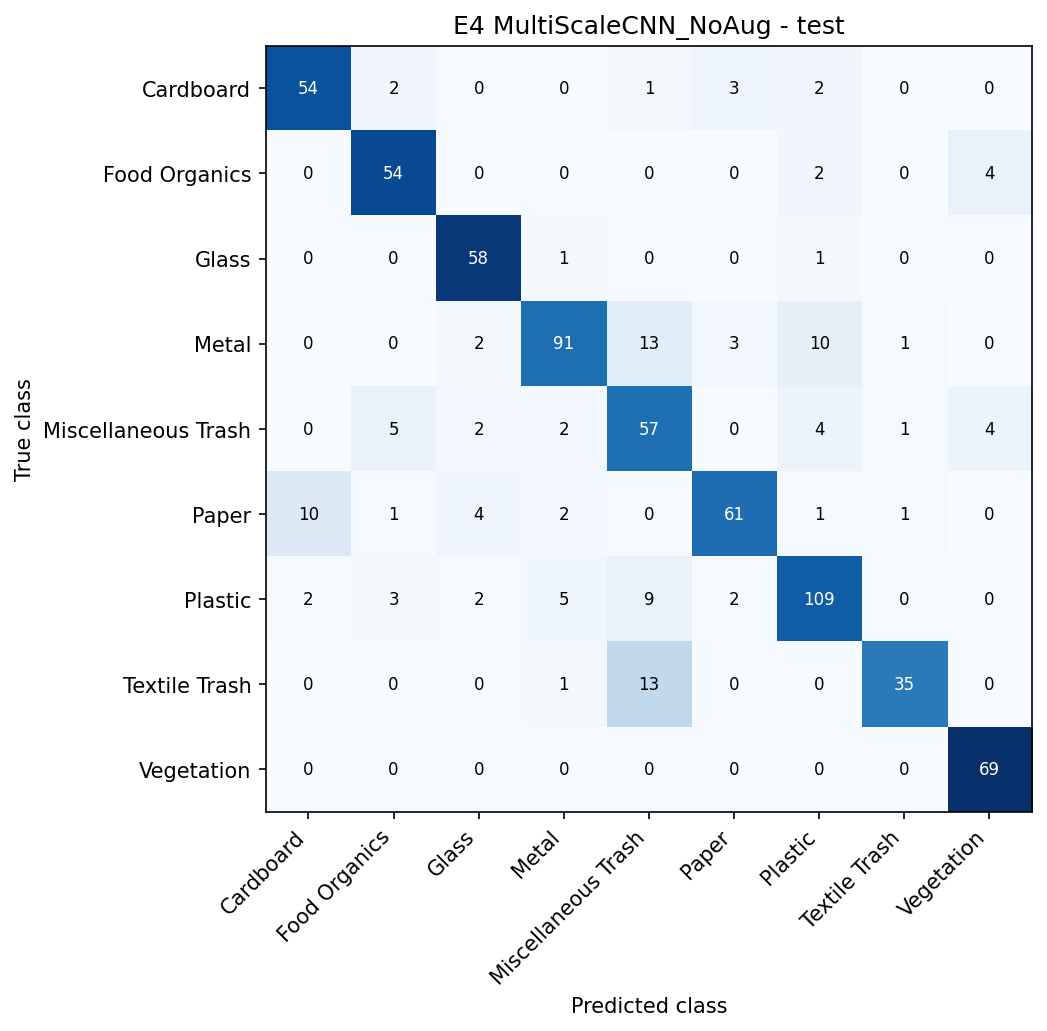

In [8]:
for exp in results:
    display(Image(filename=str(res_dir / "experiments" / exp / f"{exp}_confusion_matrix.png"), width=500))

In [9]:
# error analysis uses the model with the best VALIDATION macro-F1, never picked by test results
best = table.loc[table["best_val_macro_f1"].idxmax(), "experiment"]
errors = pd.read_csv(res_dir / "experiments" / best / f"{best}_errors.csv")
print(best, len(errors), "misclassified test images")
print(errors.groupby(["true_class", "predicted_class"]).size().sort_values(ascending=False).head(10))

E3 70 misclassified test images
true_class           predicted_class    
Textile Trash        Miscellaneous Trash    6
Miscellaneous Trash  Textile Trash          6
Metal                Plastic                5
Paper                Cardboard              5
Metal                Miscellaneous Trash    5
Plastic              Glass                  5
Vegetation           Food Organics          5
Plastic              Metal                  4
Miscellaneous Trash  Plastic                4
                     Food Organics          4
dtype: int64
